In [1]:
import pandas as pd
import numpy as np
import joblib

from pathlib import Path

PROCESSED_DIR = Path("../data/processed")

data = joblib.load(
    PROCESSED_DIR / "processed_data.joblib"
)

X_train = data["X_train"]
y_train = data["y_train"]

X_val = data["X_val"]
y_val = data["y_val"]

X_test = data["X_test"]
y_test = data["y_test"]

X_train_smote = data["X_train_smote"]
y_train_smote = data["y_train_smote"]

print("Processed data loaded successfully!")

print("\nTraining:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nSMOTE Training:", X_train_smote.shape)

print("\nSMOTE distribution:")
print(y_train_smote.value_counts())

Processed data loaded successfully!

Training: (198608, 30)
Validation: (42559, 30)
Test: (42559, 30)

SMOTE Training: (396554, 30)

SMOTE distribution:
Class
0    198277
1    198277
Name: count, dtype: int64


In [2]:
print("Training fraud cases:", y_train.sum())
print("Validation fraud cases:", y_val.sum())
print("Test fraud cases:", y_test.sum())

print("\nTraining fraud percentage:",
      y_train.mean() * 100)

print("Validation fraud percentage:",
      y_val.mean() * 100)

print("Test fraud percentage:",
      y_test.mean() * 100)

Training fraud cases: 331
Validation fraud cases: 71
Test fraud cases: 71

Training fraud percentage: 0.16665995327479255
Validation fraud percentage: 0.1668272280833666
Test fraud percentage: 0.1668272280833666


In [3]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

print("Training Logistic Regression...")

logistic_model.fit(
    X_train_smote,
    y_train_smote
)

print("Logistic Regression training completed!")

Training Logistic Regression...
Logistic Regression training completed!


In [4]:
y_val_pred = logistic_model.predict(X_val)

y_val_proba = logistic_model.predict_proba(X_val)[:, 1]

print("Validation predictions generated.")

print("Predictions:", y_val_pred.shape)
print("Probabilities:", y_val_proba.shape)

Validation predictions generated.
Predictions: (42559,)
Probabilities: (42559,)


In [5]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

accuracy = accuracy_score(y_val, y_val_pred)

precision = precision_score(
    y_val,
    y_val_pred,
    zero_division=0
)

recall = recall_score(
    y_val,
    y_val_pred,
    zero_division=0
)

f1 = f1_score(
    y_val,
    y_val_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_val,
    y_val_proba
)

pr_auc = average_precision_score(
    y_val,
    y_val_proba
)

print("=" * 50)
print("LOGISTIC REGRESSION - VALIDATION RESULTS")
print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

LOGISTIC REGRESSION - VALIDATION RESULTS
Accuracy : 0.9712
Precision: 0.0492
Recall   : 0.8873
F1 Score : 0.0933
ROC-AUC  : 0.9735
PR-AUC   : 0.6986


Confusion Matrix:
[[41271  1217]
 [    8    63]]


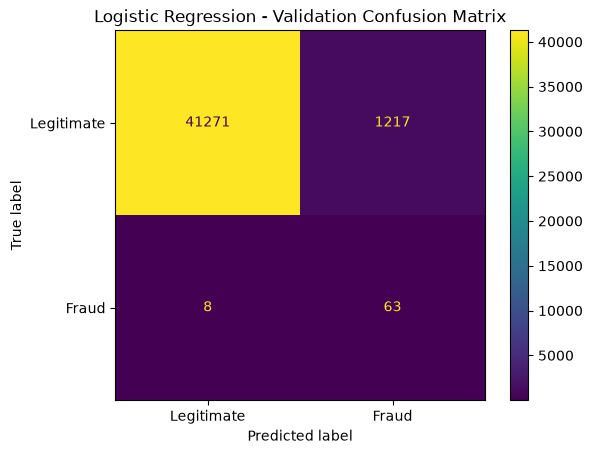

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_val,
    y_val_pred
)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot()

plt.title("Logistic Regression - Validation Confusion Matrix")
plt.show()

In [7]:
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(
    logistic_model,
    MODEL_DIR / "logistic_regression_smote.joblib"
)

print("Logistic Regression model saved successfully.")

Logistic Regression model saved successfully.


In [8]:
# Random Forest 

In [9]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")

random_forest_model.fit(
    X_train_smote,
    y_train_smote
)

print("Random Forest training completed!")

Training Random Forest...
Random Forest training completed!


In [10]:
y_val_pred_rf = random_forest_model.predict(X_val)

y_val_proba_rf = random_forest_model.predict_proba(X_val)[:, 1]

print("Random Forest validation predictions generated.")

Random Forest validation predictions generated.


In [11]:
accuracy_rf = accuracy_score(
    y_val,
    y_val_pred_rf
)

precision_rf = precision_score(
    y_val,
    y_val_pred_rf,
    zero_division=0
)

recall_rf = recall_score(
    y_val,
    y_val_pred_rf,
    zero_division=0
)

f1_rf = f1_score(
    y_val,
    y_val_pred_rf,
    zero_division=0
)

roc_auc_rf = roc_auc_score(
    y_val,
    y_val_proba_rf
)

pr_auc_rf = average_precision_score(
    y_val,
    y_val_proba_rf
)

print("=" * 50)
print("RANDOM FOREST - VALIDATION RESULTS")
print("=" * 50)

print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")
print(f"PR-AUC   : {pr_auc_rf:.4f}")

RANDOM FOREST - VALIDATION RESULTS
Accuracy : 0.9995
Precision: 0.9455
Recall   : 0.7324
F1 Score : 0.8254
ROC-AUC  : 0.9649
PR-AUC   : 0.8370


Random Forest Confusion Matrix:
[[42485     3]
 [   19    52]]


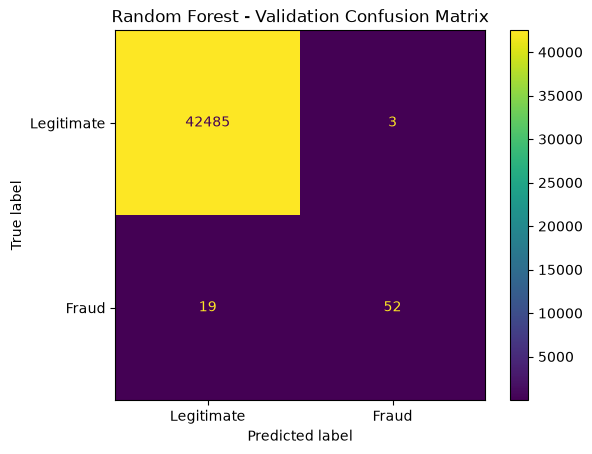

In [12]:
cm_rf = confusion_matrix(
    y_val,
    y_val_pred_rf
)

print("Random Forest Confusion Matrix:")
print(cm_rf)

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Legitimate", "Fraud"]
)

disp_rf.plot()

plt.title("Random Forest - Validation Confusion Matrix")
plt.show()

In [13]:
joblib.dump(
    random_forest_model,
    MODEL_DIR / "random_forest_smote.joblib"
)

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


In [14]:
# XGBoost

In [15]:
from xgboost import XGBClassifier
print("XGBoost import successful!")

XGBoost import successful!


In [16]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

print("Training XGBoost...")

xgb_model.fit(
    X_train_smote,
    y_train_smote
)

print("XGBoost training completed!")

Training XGBoost...
XGBoost training completed!


In [17]:
y_val_pred_xgb = xgb_model.predict(X_val)

y_val_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]

print("XGBoost validation predictions generated.")

XGBoost validation predictions generated.


In [18]:
accuracy_xgb = accuracy_score(
    y_val,
    y_val_pred_xgb
)

precision_xgb = precision_score(
    y_val,
    y_val_pred_xgb,
    zero_division=0
)

recall_xgb = recall_score(
    y_val,
    y_val_pred_xgb,
    zero_division=0
)

f1_xgb = f1_score(
    y_val,
    y_val_pred_xgb,
    zero_division=0
)

roc_auc_xgb = roc_auc_score(
    y_val,
    y_val_proba_xgb
)

pr_auc_xgb = average_precision_score(
    y_val,
    y_val_proba_xgb
)

print("=" * 50)
print("XGBOOST - VALIDATION RESULTS")
print("=" * 50)

print(f"Accuracy : {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall   : {recall_xgb:.4f}")
print(f"F1 Score : {f1_xgb:.4f}")
print(f"ROC-AUC  : {roc_auc_xgb:.4f}")
print(f"PR-AUC   : {pr_auc_xgb:.4f}")

XGBOOST - VALIDATION RESULTS
Accuracy : 0.9991
Precision: 0.7000
Recall   : 0.7887
F1 Score : 0.7417
ROC-AUC  : 0.9706
PR-AUC   : 0.7959


XGBoost Confusion Matrix:
[[42464    24]
 [   15    56]]


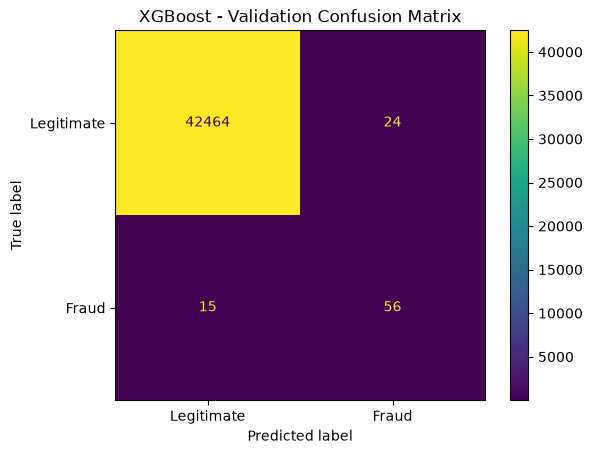

In [19]:
cm_xgb = confusion_matrix(
    y_val,
    y_val_pred_xgb
)

print("XGBoost Confusion Matrix:")
print(cm_xgb)

disp_xgb = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["Legitimate", "Fraud"]
)

disp_xgb.plot()

plt.title("XGBoost - Validation Confusion Matrix")
plt.show()

In [20]:
joblib.dump(
    xgb_model,
    MODEL_DIR / "xgboost_smote.joblib"
)

print("XGBoost model saved successfully.")

XGBoost model saved successfully.


In [21]:
# Isolation Forest

In [23]:
from sklearn.ensemble import IsolationForest

isolation_model = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

print("Training Isolation Forest...")

isolation_model.fit(X_train)

print("Isolation Forest training completed!")

Training Isolation Forest...
Isolation Forest training completed!


In [24]:
# Isolation Forest validation predictions

isolation_raw = isolation_model.predict(X_val)

# Isolation Forest:
#  1  = normal
# -1  = anomaly
#
# Convert:
#  1  -> 0 (legitimate)
# -1  -> 1 (fraud)

y_val_pred_iso = np.where(
    isolation_raw == -1,
    1,
    0
)

print("Isolation Forest validation predictions generated.")

print("\nPrediction distribution:")
print(pd.Series(y_val_pred_iso).value_counts())

Isolation Forest validation predictions generated.

Prediction distribution:
0    40957
1     1602
Name: count, dtype: int64


In [25]:
accuracy_iso = accuracy_score(
    y_val,
    y_val_pred_iso
)

precision_iso = precision_score(
    y_val,
    y_val_pred_iso,
    zero_division=0
)

recall_iso = recall_score(
    y_val,
    y_val_pred_iso,
    zero_division=0
)

f1_iso = f1_score(
    y_val,
    y_val_pred_iso,
    zero_division=0
)

print("=" * 50)
print("ISOLATION FOREST - VALIDATION RESULTS")
print("=" * 50)

print(f"Accuracy : {accuracy_iso:.4f}")
print(f"Precision: {precision_iso:.4f}")
print(f"Recall   : {recall_iso:.4f}")
print(f"F1 Score : {f1_iso:.4f}")

ISOLATION FOREST - VALIDATION RESULTS
Accuracy : 0.9633
Precision: 0.0350
Recall   : 0.7887
F1 Score : 0.0669


Isolation Forest Confusion Matrix:
[[40942  1546]
 [   15    56]]


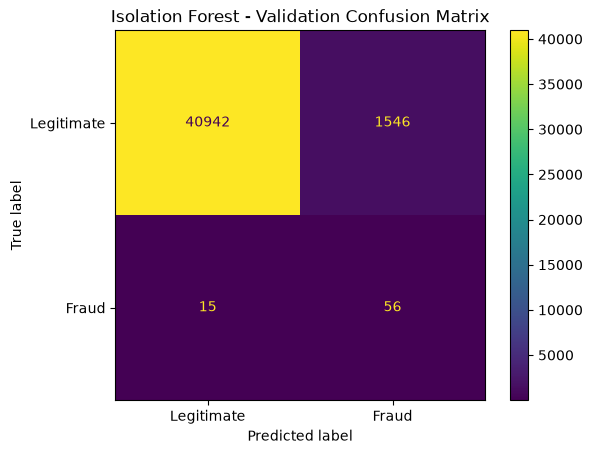

In [26]:
cm_iso = confusion_matrix(
    y_val,
    y_val_pred_iso
)

print("Isolation Forest Confusion Matrix:")
print(cm_iso)

disp_iso = ConfusionMatrixDisplay(
    confusion_matrix=cm_iso,
    display_labels=["Legitimate", "Fraud"]
)

disp_iso.plot()

plt.title("Isolation Forest - Validation Confusion Matrix")
plt.show()

In [27]:
joblib.dump(
    isolation_model,
    MODEL_DIR / "isolation_forest.joblib"
)

print("Isolation Forest model saved successfully.")

Isolation Forest model saved successfully.


In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:

    predictions = (
        y_val_proba_rf >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        predictions,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.342857,0.845070,0.487805
1,0.15,0.638298,0.845070,0.727273
2,0.20,0.779221,0.845070,0.810811
3,0.25,0.797297,0.830986,0.813793
4,0.30,0.811594,0.788732,0.800000
5,0.35,0.873016,0.774648,0.820896
6,0.40,0.898305,0.746479,0.815385
7,0.45,0.946429,0.746479,0.834646
8,0.50,0.945455,0.732394,0.825397
9,0.55,0.945455,0.732394,0.825397


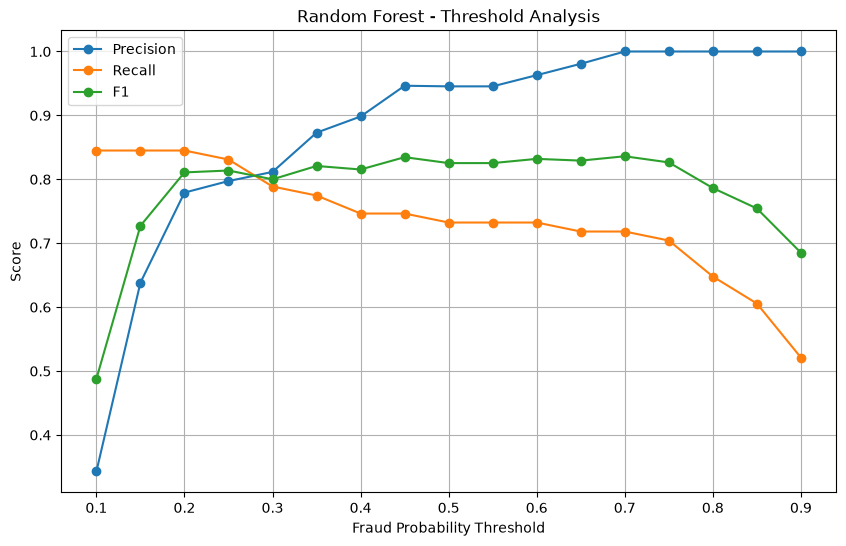

In [29]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Fraud Probability Threshold")
plt.ylabel("Score")

plt.title("Random Forest - Threshold Analysis")

plt.legend()
plt.grid(True)

plt.show()

In [30]:
# Final Test Evaluation

In [31]:
rf_test_proba = random_forest_model.predict_proba(X_test)[:, 1]

rf_test_pred = (
    rf_test_proba >= 0.70
).astype(int)

print("Random Forest test predictions generated.")

Random Forest test predictions generated.


In [32]:
rf_test_accuracy = accuracy_score(
    y_test,
    rf_test_pred
)

rf_test_precision = precision_score(
    y_test,
    rf_test_pred,
    zero_division=0
)

rf_test_recall = recall_score(
    y_test,
    rf_test_pred,
    zero_division=0
)

rf_test_f1 = f1_score(
    y_test,
    rf_test_pred,
    zero_division=0
)

rf_test_roc_auc = roc_auc_score(
    y_test,
    rf_test_proba
)

rf_test_pr_auc = average_precision_score(
    y_test,
    rf_test_proba
)

print("=" * 50)
print("RANDOM FOREST - FINAL TEST RESULTS")
print("=" * 50)

print(f"Accuracy : {rf_test_accuracy:.4f}")
print(f"Precision: {rf_test_precision:.4f}")
print(f"Recall   : {rf_test_recall:.4f}")
print(f"F1 Score : {rf_test_f1:.4f}")
print(f"ROC-AUC  : {rf_test_roc_auc:.4f}")
print(f"PR-AUC   : {rf_test_pr_auc:.4f}")

RANDOM FOREST - FINAL TEST RESULTS
Accuracy : 0.9995
Precision: 0.9455
Recall   : 0.7324
F1 Score : 0.8254
ROC-AUC  : 0.9725
PR-AUC   : 0.7931


Random Forest - Test Confusion Matrix:
[[42485     3]
 [   19    52]]


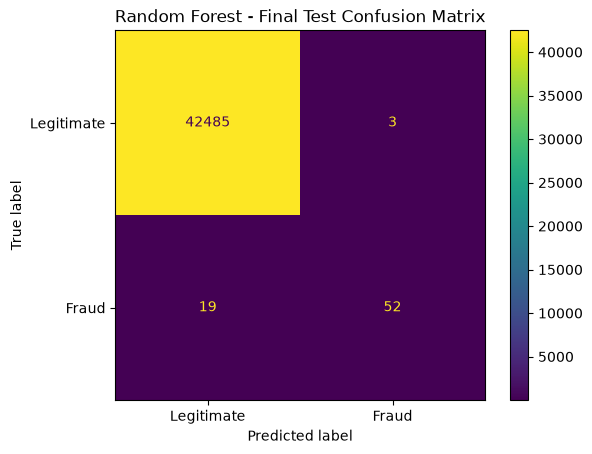

In [33]:
cm_rf_test = confusion_matrix(
    y_test,
    rf_test_pred
)

print("Random Forest - Test Confusion Matrix:")
print(cm_rf_test)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_test,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot()

plt.title(
    "Random Forest - Final Test Confusion Matrix"
)

plt.show()

In [34]:
xgb_threshold_results = []

for threshold in thresholds:

    predictions = (
        y_val_proba_xgb >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        predictions,
        zero_division=0
    )

    xgb_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

xgb_threshold_df = pd.DataFrame(
    xgb_threshold_results
)

xgb_threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.305263,0.816901,0.444444
1,0.15,0.375839,0.788732,0.509091
2,0.20,0.440945,0.788732,0.565657
3,0.25,0.523364,0.788732,0.629213
4,0.30,0.589474,0.788732,0.674699
5,0.35,0.615385,0.788732,0.691358
6,0.40,0.629213,0.788732,0.700000
7,0.45,0.636364,0.788732,0.704403
8,0.50,0.700000,0.788732,0.741722
9,0.55,0.714286,0.774648,0.743243


In [35]:
best_xgb_row = xgb_threshold_df.loc[
    xgb_threshold_df["F1"].idxmax()
]

print("Validation-selected XGBoost threshold:")
print(best_xgb_row)

Validation-selected XGBoost threshold:
Threshold    0.900000
Precision    0.945455
Recall       0.732394
F1           0.825397
Name: 16, dtype: float64


In [36]:
rf_test_proba = random_forest_model.predict_proba(X_test)[:, 1]

rf_test_pred = (
    rf_test_proba >= 0.70
).astype(int)

print("Random Forest test predictions generated.")

Random Forest test predictions generated.


In [37]:
rf_test_accuracy = accuracy_score(
    y_test,
    rf_test_pred
)

rf_test_precision = precision_score(
    y_test,
    rf_test_pred,
    zero_division=0
)

rf_test_recall = recall_score(
    y_test,
    rf_test_pred,
    zero_division=0
)

rf_test_f1 = f1_score(
    y_test,
    rf_test_pred,
    zero_division=0
)

rf_test_roc_auc = roc_auc_score(
    y_test,
    rf_test_proba
)

rf_test_pr_auc = average_precision_score(
    y_test,
    rf_test_proba
)

print("=" * 55)
print("RANDOM FOREST - FINAL TEST RESULTS")
print("=" * 55)

print(f"Accuracy : {rf_test_accuracy:.4f}")
print(f"Precision: {rf_test_precision:.4f}")
print(f"Recall   : {rf_test_recall:.4f}")
print(f"F1 Score : {rf_test_f1:.4f}")
print(f"ROC-AUC  : {rf_test_roc_auc:.4f}")
print(f"PR-AUC   : {rf_test_pr_auc:.4f}")

RANDOM FOREST - FINAL TEST RESULTS
Accuracy : 0.9995
Precision: 0.9455
Recall   : 0.7324
F1 Score : 0.8254
ROC-AUC  : 0.9725
PR-AUC   : 0.7931



Random Forest Test Confusion Matrix:
[[42485     3]
 [   19    52]]


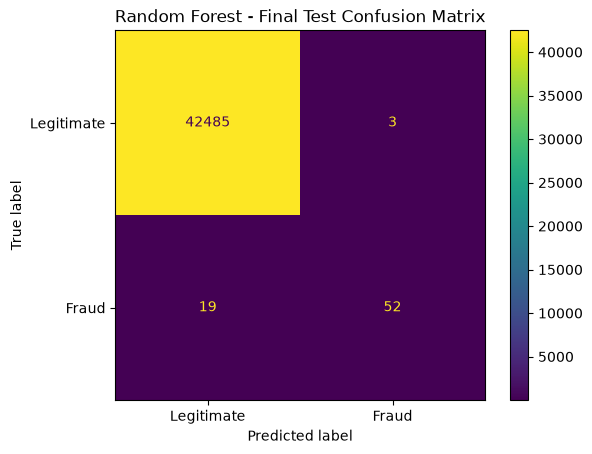

In [38]:
cm_rf_test = confusion_matrix(
    y_test,
    rf_test_pred
)

print("\nRandom Forest Test Confusion Matrix:")
print(cm_rf_test)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_test,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot()

plt.title("Random Forest - Final Test Confusion Matrix")
plt.show()

In [39]:
xgb_test_proba = xgb_model.predict_proba(X_test)[:, 1]

xgb_test_pred = (
    xgb_test_proba >= 0.90
).astype(int)

print("XGBoost test predictions generated.")

XGBoost test predictions generated.


In [40]:
xgb_test_accuracy = accuracy_score(
    y_test,
    xgb_test_pred
)

xgb_test_precision = precision_score(
    y_test,
    xgb_test_pred,
    zero_division=0
)

xgb_test_recall = recall_score(
    y_test,
    xgb_test_pred,
    zero_division=0
)

xgb_test_f1 = f1_score(
    y_test,
    xgb_test_pred,
    zero_division=0
)

xgb_test_roc_auc = roc_auc_score(
    y_test,
    xgb_test_proba
)

xgb_test_pr_auc = average_precision_score(
    y_test,
    xgb_test_proba
)

print("=" * 55)
print("XGBOOST - FINAL TEST RESULTS")
print("=" * 55)

print(f"Accuracy : {xgb_test_accuracy:.4f}")
print(f"Precision: {xgb_test_precision:.4f}")
print(f"Recall   : {xgb_test_recall:.4f}")
print(f"F1 Score : {xgb_test_f1:.4f}")
print(f"ROC-AUC  : {xgb_test_roc_auc:.4f}")
print(f"PR-AUC   : {xgb_test_pr_auc:.4f}")

XGBOOST - FINAL TEST RESULTS
Accuracy : 0.9994
Precision: 0.8852
Recall   : 0.7606
F1 Score : 0.8182
ROC-AUC  : 0.9726
PR-AUC   : 0.7818



XGBoost Test Confusion Matrix:
[[42481     7]
 [   17    54]]


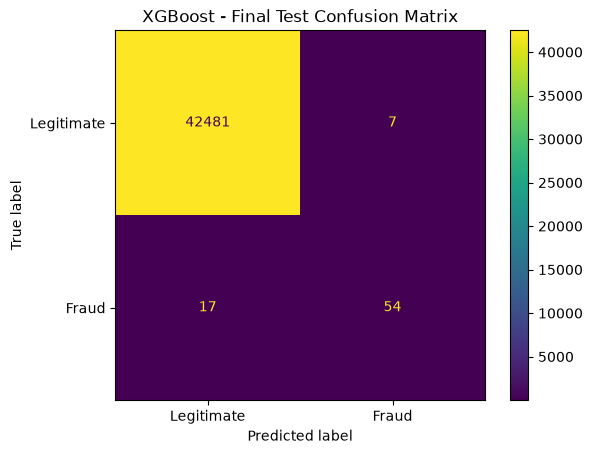

In [41]:
cm_xgb_test = confusion_matrix(
    y_test,
    xgb_test_pred
)

print("\nXGBoost Test Confusion Matrix:")
print(cm_xgb_test)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb_test,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot()

plt.title("XGBoost - Final Test Confusion Matrix")
plt.show()

In [42]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Threshold": [
        0.50,
        0.70,
        0.90
    ],
    "Precision": [
        precision,
        rf_test_precision,
        xgb_test_precision
    ],
    "Recall": [
        recall,
        rf_test_recall,
        xgb_test_recall
    ],
    "F1": [
        f1,
        rf_test_f1,
        xgb_test_f1
    ],
    "ROC_AUC": [
        roc_auc,
        rf_test_roc_auc,
        xgb_test_roc_auc
    ],
    "PR_AUC": [
        pr_auc,
        rf_test_pr_auc,
        xgb_test_pr_auc
    ]
})

final_results

,Model,Threshold,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.5,0.945455,0.732394,0.825397,0.973487,0.698576
1,Random Forest,0.7,0.945455,0.732394,0.825397,0.972482,0.793082
2,XGBoost,0.9,0.885246,0.760563,0.818182,0.972637,0.781847


In [43]:
final_test_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost"
    ],
    "Threshold": [
        0.70,
        0.90
    ],
    "Accuracy": [
        rf_test_accuracy,
        xgb_test_accuracy
    ],
    "Precision": [
        rf_test_precision,
        xgb_test_precision
    ],
    "Recall": [
        rf_test_recall,
        xgb_test_recall
    ],
    "F1": [
        rf_test_f1,
        xgb_test_f1
    ],
    "ROC_AUC": [
        rf_test_roc_auc,
        xgb_test_roc_auc
    ],
    "PR_AUC": [
        rf_test_pr_auc,
        xgb_test_pr_auc
    ]
})

final_test_results

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Random Forest,0.7,0.999483,0.945455,0.732394,0.825397,0.972482,0.793082
1,XGBoost,0.9,0.999436,0.885246,0.760563,0.818182,0.972637,0.781847


In [44]:
RESULTS_DIR = Path("./outputs")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

final_test_results.to_csv(
    RESULTS_DIR / "final_test_results.csv",
    index=False
)

print("Final test results saved successfully.")

Final test results saved successfully.
